<a href="https://colab.research.google.com/github/Andremil/tcc/blob/main/cumarutccartigos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install metapub
!pip install pdfplumber
!pip install fitz
!pip install frontend
!pip install PyMuPDF
!pip install PyPDF2

In [ ]:
import numpy as np
import pandas as pd
import json
from metapub import PubMedFetcher
import os
os.environ['NCBI_API_KEY'] = '98e8ac592ff4555581d45d225be2d4831c08'

2025-06-14 15:01:52 3b4ac03b07b2 metapub.config[10099] WARNING NCBI_API_KEY was not set.


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
import csv
from metapub import PubMedFetcher
import io  # Importe io para usar StringIO

# Initialize the fetcher
fetcher = PubMedFetcher()

# Define a complex query including free full text and year range
query = (
    '("postpartum hemorrhage" OR "hemorragia puerperal") AND '
    '("uterine atony" OR "hypotonia uterina") AND '
    '('
    '"new therapies" OR "novel treatment" OR "emerging therapies" OR "innovative treatment" OR '
    '"surgical treatment" OR "surgical intervention" OR "surgery" OR "minimally invasive surgery" OR '
    '"embolization" OR "uterine artery embolization" OR "ligation" OR "ligation of uterine artery" OR '
    '"balloon tamponade" OR "Bakri balloon" OR "compression sutures" OR "B-Lynch suture"'
    ') AND '
    '("2020/01/01"[PDAT] : "2025/05/31"[PDAT])'
)


# Fetch PMIDs for the complex query
pmids = fetcher.pmids_for_query(query)

# Lista de propriedades para extrair com base na verificação de propriedades disponíveis
properties = [
    'abstract', 'author1_last_fm', 'author1_lastfm', 'author_list', 'authors', 'authors_str',
    'book_abstracts', 'book_accession_id', 'book_contribution_date', 'book_copyright',
    'book_date_revised', 'book_editors', 'book_history', 'book_language', 'book_medium',
    'book_publication_status', 'book_publisher', 'book_sections', 'book_synonyms',
    'book_title', 'chemicals', 'citation', 'citation_html', 'content', 'doi', 'first_page',
    'grants', 'history', 'issn', 'issue', 'journal', 'last_page', 'mesh', 'pages', 'parse_xml',
    'pii', 'pmc', 'pmid', 'pmcid', 'publication_types', 'pubmed_type', 'title', 'to_dict', 'url',
    'volume', 'volume_issue', 'xml', 'year'
]


# Nome do arquivo CSV
csv_filename = 'articleslucas.csv'

# Lista para armazenar os dados dos artigos
article_data_list = []

# Iterar pelos PMIDs e obter os dados dos artigos
for pmid in pmids:
    article = fetcher.article_by_pmid(pmid)
    article_data = []

    # Iterar pelas propriedades e extrair os dados do artigo
    for prop in properties:
        if hasattr(article, prop):
            article_data.append(getattr(article, prop))
        else:
            article_data.append('')  # Se a propriedade não estiver disponível, adicione uma string vazia

    # Adicionar os dados do artigo à lista
    article_data_list.append(article_data)

# Escrever os dados no arquivo CSV
with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
    csvwriter = csv.writer(csvfile)

    # Escrever o cabeçalho com os nomes das propriedades
    csvwriter.writerow(properties)

    # Escrever os dados de cada artigo
    csvwriter.writerows(article_data_list)

print(f"Dados dos artigos foram salvos em {csv_filename}")


Dados dos artigos foram salvos em articleslucas.csv


In [ ]:
data = pd.read_csv(csv_filename)

In [ ]:
data

,abstract,author1_last_fm,author1_lastfm,author_list,authors,authors_str,book_abstracts,book_accession_id,book_contribution_date,book_copyright,...,pmcid,publication_types,pubmed_type,title,to_dict,url,volume,volume_issue,xml,year
0,"OBJECTIVES: Endometrial tuberculosis, which co...",Jiang J,JiangJ,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Jiang J', 'Xu D', 'Yang Y']",Jiang J; Xu D; Yang Y,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,Hysteroscopic adhesiolysis and fertility outco...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/40457790,50,50(1),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
1,Background Uterine balloon tamponade (UBT) has...,Santhoshi D,SanthoshiD,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Santhoshi D', 'Yaliwal RG', 'Patil N', 'Bira...",Santhoshi D; Yaliwal RG; Patil N; Biradar A,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,Comparative Study of the Safety and Efficacy o...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/40352012,17,17(4),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
2,INTRODUCTION: Etiologies of postpartum hemorrh...,Tyagi P,TyagiP,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Tyagi P', 'Anamika', 'Verma P', 'Anand D']",Tyagi P; Anamika; Verma P; Anand D,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,Comparative Analysis of Panicker's Vacuum Suct...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/40308400,17,17(3),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
3,BACKGROUND: Peripartum hysterectomy (PH) is a ...,Desalegn H,DesalegnH,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Desalegn H', 'Geta A', 'Nane D']",Desalegn H; Geta A; Nane D,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,"Peripartum hysterectomy: prevalence, indicatio...",<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/40275178,25,25(1),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
4,Objective: This study aimed to analyze and com...,Włodarczyk Z,WłodarczykZ,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Włodarczyk Z', 'Śliwka A', 'Maciocha H', 'Pa...",Włodarczyk Z; Śliwka A; Maciocha H; Paruszewsk...,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,The Role of Accurate Estimations of Blood Loss...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/40142668,14,14(6),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,OBJECTIVE: This study was performed to explore...,Chen L,ChenL,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Chen L', 'Wu B', 'Han Q', 'Yan J']",Chen L; Wu B; Han Q; Yan J,NaN,NaN,NaN,NaN,...,NaN,{'D016428': 'Journal Article'},article,Clinical analysis of emergency exploratory lap...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/31662015,48,48(2),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2020
123,INTRODUCTION: Peripartum hysterectomy is usual...,Maraschini A,MaraschiniA,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Maraschini A', 'Lega I', ""D'Aloja P"", 'Buonc...",Maraschini A; Lega I; D'Aloja P; Buoncristiano...,NaN,NaN,NaN,NaN,...,NaN,"{'D016428': 'Journal Article', 'D016448': 'Mul...",article,Women undergoing peripartum hysterectomy due t...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/31520414,99,99(2),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2020
124,Background: Postpartum hemorrhage (PPH) is a d...,Said Ali A,SaidAliA,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Said Ali A', 'Faraag E', 'Mohammed M', 'Elma...",Said Ali A; Faraag E; Mohammed M; Elmarghany Z...,NaN,NaN,NaN,NaN,...,NaN,"{'D016428': 'Journal Article', 'D000078182': '...",article,The safety and effe

In [ ]:
data.to_csv('drive/My Drive/datalucas.csv')

In [ ]:
data = pd.read_csv('drive/My Drive/datalucas.csv')

In [ ]:
df = data.iloc[:,1:]

In [ ]:
# Definindo as listas de termos para cada categoria a ser filtrada a partir do abstract



In [ ]:
objective_terms = [
    "objective", "aim", "purpose", "goal", "research question", "hypothesis", "focus", "intent", "problem", "study design",
    "research aim", "study purpose", "research goal", "study objective", "research focus", "investigation objective", "main goal", "primary goal",
    "study hypothesis", "central aim", "primary objective", "intended purpose"
]


In [ ]:
method_terms = [
    "methodology", "method", "approach", "technique", "design", "data collection", "procedure", "experiment", "analysis", "sampling",
    "instrument", "statistical analysis", "research method", "research design", "data analysis", "experimental method", "quantitative method",
    "qualitative method", "survey", "measurement", "testing", "protocol", "statistical procedure", "research approach", "empirical method",
    "data gathering", "data collection process"
]


In [ ]:
result_terms = [
    "results", "findings", "outcome", "data", "analysis results", "discovery", "observation", "significant", "association", "impact",
    "difference", "effect", "conclusion", "findings indicate", "results suggest", "evidence shows", "observed", "significant difference",
    "statistical result", "outcome shows", "data analysis", "key results", "major findings", "main outcome"
]


In [ ]:
conclusion_terms = [
    "conclusion", "implications", "recommendations", "consequence", "suggestion", "interpretation", "summary", "contribution",
    "practical implications", "future work", "limitations", "final thoughts", "research implications", "study conclusion", "key takeaways",
    "main conclusion", "research recommendations", "interpretation of results", "study limitations", "future directions", "policy implications"
]


In [ ]:
human_health_terms = [
    # Fármacos tradicionais e recentes
    "tranexamic acid", "carbetocin", "misoprostol", "oxytocin", "carboprost", "ergometrine",
    "syntocinon", "uterotonics", "hemostatic agents",

    # Procedimentos e técnicas modernas
    "uterine balloon tamponade", "Bakri balloon", "non-pneumatic anti-shock garment",
    "uterine artery embolization", "interventional radiology", "embolization",
    "minimally invasive surgery", "laparoscopy", "laparotomy",
    "compression sutures", "B-Lynch suture", "stepwise uterine devascularization",
    "internal iliac artery ligation", "pelvic artery ligation",

    # Novas abordagens e terapias emergentes
    "point-of-care ultrasound", "damage control resuscitation", "massive transfusion protocol",
    "early warning system", "shock index", "active management of third stage labor",
    "evidence-based medicine", "clinical guidelines", "practice guidelines",
    "protocol", "treatment protocol", "randomized controlled trial", "clinical trial",
    "therapeutic strategy", "innovative treatment", "emerging therapy", "novel treatment",
    "multimodal therapy", "combined therapy", "adjunct therapy", "personalized medicine",
    "precision medicine", "digital health", "telemedicine", "health technology",

    # Resultados e monitoramento
    "treatment outcome", "treatment effectiveness", "clinical outcome", "patient recovery",
    "postpartum care", "maternal morbidity", "maternal mortality", "postpartum hemorrhage prevention"
]


In [ ]:
# Filtrando os abstracts com pelo menos um termo de cada categoria
df_filtered = df[
    df['abstract'].str.contains("|".join(objective_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(method_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(result_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(conclusion_terms), case=False, na=False) &
    df['abstract'].str.contains("|".join(human_health_terms), case=False, na=False)
]

In [ ]:
import ast
import pandas as pd

# Códigos MeSH dos Top 4 tipos de estudo
codigos_top4 = {
    'D016449',       # Randomized Controlled Trial
    'D000078182',    # Systematic Review
    'D017418',       # Meta-Analysis
    'D016448',       # Multicenter Study
}

# Função para converter string em dicionário (se necessário)
def parse_dict_if_needed(val):
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return {}
    return val

# Aplicar a conversão de forma segura com .loc
df_filtered.loc[:, 'publication_types'] = df_filtered['publication_types'].apply(parse_dict_if_needed)

# Função para verificar se o dicionário contém algum dos códigos dos Top 4
def contem_top4(pub_types):
    if not isinstance(pub_types, dict):
        return False
    return any(cod in pub_types for cod in codigos_top4)

# Filtrar o DataFrame
df_final = df_filtered[df_filtered['publication_types'].apply(contem_top4)]

# Mostrar o número de artigos filtrados
print(f"Número de artigos com tipos Top 4: {len(df_final)}")

# Salvar os dados filtrados em um arquivo CSV
df_final.to_csv('artigos_top4_publication_types.csv', index=False)



Número de artigos com tipos Top 4: 11


In [ ]:
data_final = pd.read_csv('artigos_top4_publication_types.csv')

In [ ]:
data_final

,abstract,author1_last_fm,author1_lastfm,author_list,authors,authors_str,book_abstracts,book_accession_id,book_contribution_date,book_copyright,...,pmcid,publication_types,pubmed_type,title,to_dict,url,volume,volume_issue,xml,year
0,BACKGROUND: Preclinical studies have documente...,Raguramane S,RaguramaneS,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Raguramane S', 'Mishra SK', 'Jha N', 'Parida...",Raguramane S; Mishra SK; Jha N; Parida S; Jha AK,NaN,NaN,NaN,NaN,...,NaN,"{'D016428': 'Journal Article', 'D016449': 'Ran...",article,Effect of phenylephrine infusion on postpartum...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/39778809,7,7(2),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2025
1,BACKGROUND: No standard treatment guidelines h...,Jung YW,JungYW,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Jung YW', 'Kim J', 'Shin WK', 'Song SY', 'Ch...",Jung YW; Kim J; Shin WK; Song SY; Choi JS; Hyu...,NaN,NaN,NaN,NaN,...,NaN,"{'D016428': 'Journal Article', 'D016448': 'Mul...",article,Outcomes and prognosis of postpartum hemorrhag...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/39090705,19,19(1),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2024
2,OBJECTIVE: To evaluate whether prophylactic ad...,Ansari JR,AnsariJR,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Ansari JR', 'Yarmosh A', 'Michel G', 'Lyell ...",Ansari JR; Yarmosh A; Michel G; Lyell D; Hedli...,NaN,NaN,NaN,NaN,...,NaN,"{'D016449': 'Randomized Controlled Trial', 'D0...",article,Intravenous Calcium to Decrease Blood Loss Dur...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/37917943,143,143(1),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2024
3,OBJECTIVE: To evaluate angiographic findings a...,Kim SH,KimSH,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Kim SH', 'Han K', 'Shin JH', 'Kim J', 'Hyun ...",Kim SH; Han K; Shin JH; Kim J; Hyun DH; Lee MY,NaN,NaN,NaN,NaN,...,NaN,"{'D016448': 'Multicenter Study', 'D016428': 'J...",article,Repeat uterine artery embolization (UAE) for r...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/36786903,33,33(7),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2023
4,OBJECTIVE: To assess the prevalence of intraut...,Zouaghi C,ZouaghiC,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Zouaghi C', 'Chaouch MA', 'Sanchez S', 'Zoua...",Zouaghi C; Chaouch MA; Sanchez S; Zouaghi S,NaN,NaN,NaN,NaN,...,NaN,"{'D000078182': 'Systematic Review', 'D016428':...",article,Hysteroscopy after conservative surgical treat...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/36710527,162,162(2),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2023
5,"OBJECTIVE: To describe the incidence, indicati...",Kallianidis AF,KallianidisAF,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Kallianidis AF', 'Rijntjes D', 'Brobbel C', ...",Kallianidis AF; Rijntjes D; Brobbel C; Dekkers...,NaN,NaN,NaN,NaN,...,NaN,"{'D017418': 'Meta-Analysis', 'D000078182': 'Sy...",article,"Incidence, Indications, Risk Factors, and Outc...",<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/36701608,141,141(1),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2023
6,OBJECTIVES: To evaluate uterine tamponade devi...,Pingray V,PingrayV,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Pingray V', 'Widmer M', 'Ciapponi A', 'Hofme...",Pingray V; Widmer M; Ciapponi A; Hofmeyr GJ; D...,NaN,NaN,NaN,NaN,...,NaN,"{'D016428': 'Journal Article', 'D000078182': '...",article,Effectiveness of uterine tamponade devices for...,<bound method PubMedArticle.to_dict of <metapu...,https://ncbi.nlm.nih.gov/pubmed/34165867,128,128(11),"b'<?xml version=""1.0"" ?>\n<!DOCTYPE PubmedArti...",2021
7,"Objective-to overview, compare and generalize ...",Baliuliene V,BaliulieneV,[<metapub.pubmedauthor.PubMedAuthor object at ...,"['Baliuliene V', 'Vi

In [ ]:
# salvando os dados filtrados como df_filtered.csv
data_final.to_csv('drive/My Drive/lucasfinal1.csv')

In [ ]:
#lendo os dados filtrados a partir do google drive
df = pd.read_csv('drive/My Drive/lucasfinal1.csv')


In [ ]:
#selecionando colunas mais relevantes para os nossa base de dados final
df_tcc = df[['abstract', 'authors', 'chemicals', 'citation', 'doi', 'history', 'issn', 'journal', 'title', 'volume', 'volume_issue', 'year', 'url','history']]



In [ ]:
df_tcc

,abstract,authors,chemicals,citation,doi,history,issn,journal,title,volume,volume_issue,year,url,history
0,BACKGROUND: Preclinical studies have documente...,"['Raguramane S', 'Mishra SK', 'Jha N', 'Parida...",{'D010656': {'substance_name': 'Phenylephrine'...,"Raguramane S, et al. Effect of phenylephrine i...",10.1016/j.ajogmf.2024.101593,"{'received': datetime.datetime(2024, 10, 9, 0,...",2589-9333,Am J Obstet Gynecol MFM,Effect of phenylephrine infusion on postpartum...,7,7(2),2025,https://ncbi.nlm.nih.gov/pubmed/39778809,"{'received': datetime.datetime(2024, 10, 9, 0,..."
1,BACKGROUND: No standard treatment guidelines h...,"['Jung YW', 'Kim J', 'Shin WK', 'Song SY', 'Ch...","{'D019344': {'substance_name': 'Lactic Acid', ...","Jung YW, et al. Outcomes and prognosis of post...",10.1186/s13017-024-00556-5,"{'received': datetime.datetime(2024, 4, 28, 0,...",1749-7922,World J Emerg Surg,Outcomes and prognosis of postpartum hemorrhag...,19,19(1),2024,https://ncbi.nlm.nih.gov/pubmed/39090705,"{'received': datetime.datetime(2024, 4, 28, 0,..."
2,OBJECTIVE: To evaluate whether prophylactic ad...,"['Ansari JR', 'Yarmosh A', 'Michel G', 'Lyell ...","{'D010121': {'substance_name': 'Oxytocin', 're...","Ansari JR, et al. Intravenous Calcium to Decre...",10.1097/AOG.0000000000005441,"{'received': datetime.datetime(2023, 8, 4, 0, ...",1873-233X,Obstet Gynecol,Intravenous Calcium to Decrease Blood Loss Dur...,143,143(1),2024,https://ncbi.nlm.nih.gov/pubmed/37917943,"{'received': datetime.datetime(2023, 8, 4, 0, ..."
3,OBJECTIVE: To evaluate angiographic findings a...,"['Kim SH', 'Han K', 'Shin JH', 'Kim J', 'Hyun ...",{},"Kim SH, et al. Repeat uterine artery embolizat...",10.1007/s00330-023-09440-3,"{'received': datetime.datetime(2022, 7, 5, 0, ...",1432-1084,Eur Radiol,Repeat uterine artery embolization (UAE) for r...,33,33(7),2023,https://ncbi.nlm.nih.gov/pubmed/36786903,"{'received': datetime.datetime(2022, 7, 5, 0, ..."
4,OBJECTIVE: To assess the prevalence of intraut...,"['Zouaghi C', 'Chaouch MA', 'Sanchez S', 'Zoua...",{},"Zouaghi C, et al. Hysteroscopy after conservat...",10.1002/ijgo.14704,"{'revised': datetime.datetime(2023, 1, 20, 0, ...",1879-3479,Int J Gynaecol Obstet,Hysteroscopy after conservative surgical treat...,162,162(2),2023,https://ncbi.nlm.nih.gov/pubmed/36710527,"{'revised': datetime.datetime(2023, 1, 20, 0, ..."
5,"OBJECTIVE: To describe the incidence, indicati...","['Kallianidis AF', 'Rijntjes D', 'Brobbel C', ...",{},"Kallianidis AF, et al. Incidence, Indications,...",10.1097/AOG.0000000000005022,"{'received': datetime.datetime(2022, 7, 22, 0,...",1873-233X,Obstet Gynecol,"Incidence, Indications, Risk Factors, and Outc...",141,141(1),2023,https://ncbi.nlm.nih.gov/pubmed/36701608,"{'received': datetime.datetime(2022, 7, 22, 0,..."
6,OBJECTIVES: To evaluate uterine tamponade devi...,"['Pingray V', 'Widmer M', 'Ciapponi A', 'Hofme...",{},"Pingray V, et al. Effectiveness of uterine tam...",10.1111/1471-0528.16819,"{'accepted': datetime.datetime(2021, 4, 16, 0,...",1471-0528,BJOG,Effectiveness of uterine tamponade devices for...,128,128(11),2021,https://ncbi.nlm.nih.gov/pubmed/34165867,"{'accepted': datetime.datetime(2021, 4, 16, 0,..."
7,"Objective-to overview, compare and generalize ...","['Baliuliene V', 'Vitartaite M', 'Rimaitis K']","{'D010120': {'substance_name': 'Oxytocics', 'r...","Baliuliene V, et al. Prophylactic Dose of Oxyt...",10.3390/ijerph18095029,"{'received': datetime.datetime(2021, 4, 8, 0, ...",1660-4601,Int J Environ Res Public Health,Prophylactic Dose of Oxytocin for Uterine Aton...,18,18(9),2021,https://ncbi.nlm.nih.gov/pubmed/34068723,"{'received': datetime.datetime(2021, 4, 8, 0, ..."
8,IMPORTANCE: Postpartum hemorrhage (PPH) is an ...,"['Zhang XQ', 'Chen XT', 'Zhang YT', 'Mai CX']",{},"Zhang XQ, et al. The Emergent Pelvic Artery Em...",10.1097/OGX.0000000000000887,"{'entrez': datetime.datetime(2021, 4, 28, 0, 0...",1533-9866,Obstet Gynecol Surv,The Emergent Pelvic Artery Embolization in the...,7

In [ ]:
#salvando no drive novamente como tccData.csv
df_tcc.to_csv('drive/My Drive/lucasfinaldata.csv')

In [ ]:
#lendo do drive novamente como tccData.csv
df = pd.read_csv('drive/My Drive/lucasfinaldata.csv')


In [ ]:
'''#inserindo colunas para objetivos, metodologia e resultados
df.insert(2, "objectives", [None] * len(df))   # Insere na posição 2
df.insert(3, "methodology", [None] * len(df))  # Insere na posição 3
df.insert(4, "results", [None] * len(df))      # Insere na posição 4
# salvando dados para analise manual
df.to_csv('drive/My Drive/mydata.csv')'''

In [ ]:
# realizada analise manual a partir do resumo e exluido alguns artigos motivo da exclusão abaixo
# inserida coluna participaintginstituitions obtidas a partir da ulr dos resumo no pubmed

2025-06-14 15:39:02 3b4ac03b07b2 matplotlib.category[10099] INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
<ipython-input-52-75043607>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='year', palette='Blues')  # Use o palette para cores mais atraentes
2025-06-14 15:39:02 3b4ac03b07b2 matplotlib.category[10099] INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


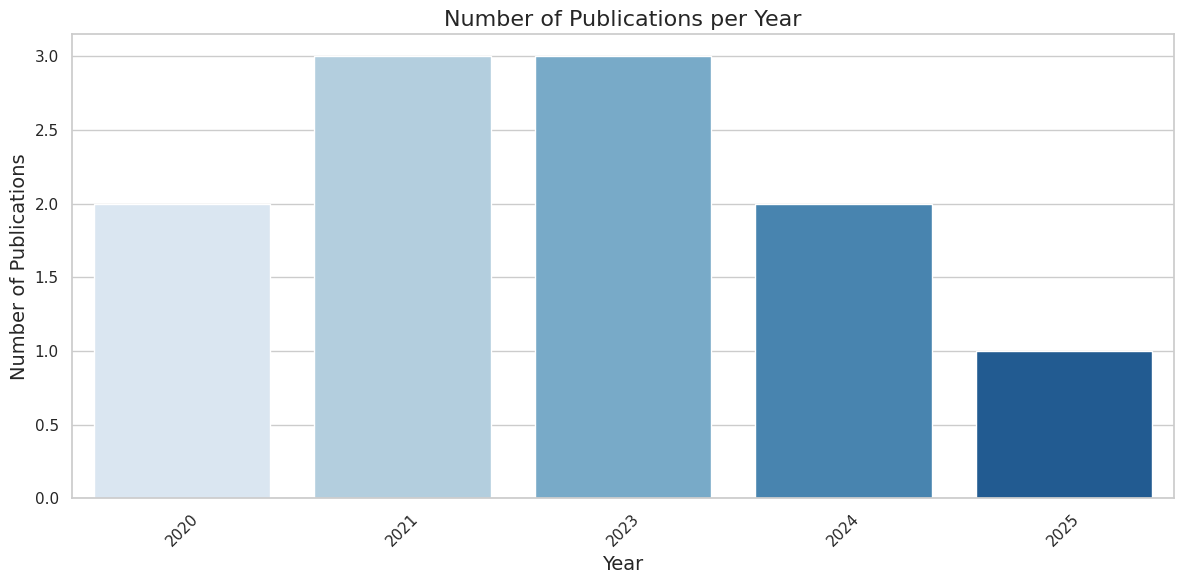

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vamos usar a função 'countplot' do seaborn para contar os valores por ano
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")  # Definindo o estilo de fundo para o gráfico
sns.countplot(data=df, x='year', palette='Blues')  # Use o palette para cores mais atraentes

plt.title('Number of Publications per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Publications', fontsize=14)
plt.xticks(rotation=45)  # Rotaciona os rótulos do eixo x, caso necessário
plt.tight_layout()  # Ajusta o layout para não cortar texto
plt.show()



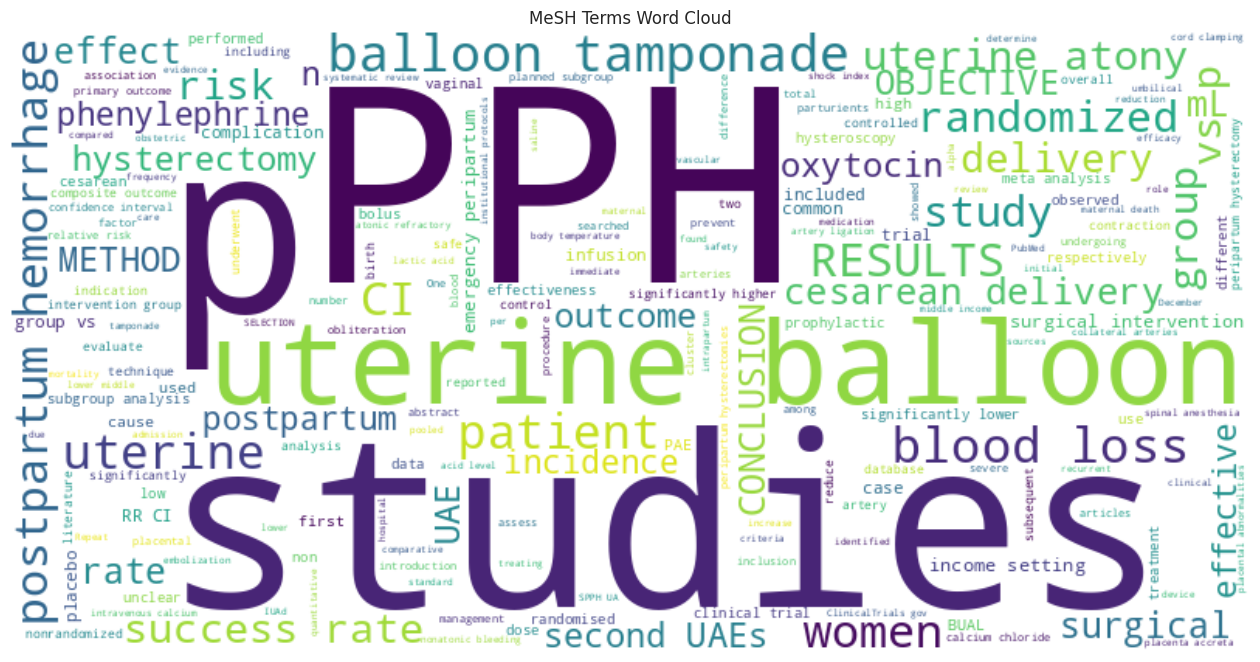

In [ ]:
from wordcloud import WordCloud

# Generating the word cloud for MeSH terms
text = ' '.join(df['abstract'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(16, 12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('MeSH Terms Word Cloud')
plt.show()

In [ ]:
df.columns

Index(['Unnamed: 0', 'abstract', 'authors', 'chemicals', 'citation', 'doi',
       'history', 'issn', 'journal', 'title', 'volume', 'volume_issue', 'year',
       'url', 'history.1'],
      dtype='object')

In [ ]:
df = df.drop(df.columns[0], axis=1)


In [ ]:
df

,abstract,authors,chemicals,citation,doi,history,issn,journal,title,volume,volume_issue,year,url,history.1
0,BACKGROUND: Preclinical studies have documente...,"['Raguramane S', 'Mishra SK', 'Jha N', 'Parida...",{'D010656': {'substance_name': 'Phenylephrine'...,"Raguramane S, et al. Effect of phenylephrine i...",10.1016/j.ajogmf.2024.101593,"{'received': datetime.datetime(2024, 10, 9, 0,...",2589-9333,Am J Obstet Gynecol MFM,Effect of phenylephrine infusion on postpartum...,7,7(2),2025,https://ncbi.nlm.nih.gov/pubmed/39778809,"{'received': datetime.datetime(2024, 10, 9, 0,..."
1,BACKGROUND: No standard treatment guidelines h...,"['Jung YW', 'Kim J', 'Shin WK', 'Song SY', 'Ch...","{'D019344': {'substance_name': 'Lactic Acid', ...","Jung YW, et al. Outcomes and prognosis of post...",10.1186/s13017-024-00556-5,"{'received': datetime.datetime(2024, 4, 28, 0,...",1749-7922,World J Emerg Surg,Outcomes and prognosis of postpartum hemorrhag...,19,19(1),2024,https://ncbi.nlm.nih.gov/pubmed/39090705,"{'received': datetime.datetime(2024, 4, 28, 0,..."
2,OBJECTIVE: To evaluate whether prophylactic ad...,"['Ansari JR', 'Yarmosh A', 'Michel G', 'Lyell ...","{'D010121': {'substance_name': 'Oxytocin', 're...","Ansari JR, et al. Intravenous Calcium to Decre...",10.1097/AOG.0000000000005441,"{'received': datetime.datetime(2023, 8, 4, 0, ...",1873-233X,Obstet Gynecol,Intravenous Calcium to Decrease Blood Loss Dur...,143,143(1),2024,https://ncbi.nlm.nih.gov/pubmed/37917943,"{'received': datetime.datetime(2023, 8, 4, 0, ..."
3,OBJECTIVE: To evaluate angiographic findings a...,"['Kim SH', 'Han K', 'Shin JH', 'Kim J', 'Hyun ...",{},"Kim SH, et al. Repeat uterine artery embolizat...",10.1007/s00330-023-09440-3,"{'received': datetime.datetime(2022, 7, 5, 0, ...",1432-1084,Eur Radiol,Repeat uterine artery embolization (UAE) for r...,33,33(7),2023,https://ncbi.nlm.nih.gov/pubmed/36786903,"{'received': datetime.datetime(2022, 7, 5, 0, ..."
4,OBJECTIVE: To assess the prevalence of intraut...,"['Zouaghi C', 'Chaouch MA', 'Sanchez S', 'Zoua...",{},"Zouaghi C, et al. Hysteroscopy after conservat...",10.1002/ijgo.14704,"{'revised': datetime.datetime(2023, 1, 20, 0, ...",1879-3479,Int J Gynaecol Obstet,Hysteroscopy after conservative surgical treat...,162,162(2),2023,https://ncbi.nlm.nih.gov/pubmed/36710527,"{'revised': datetime.datetime(2023, 1, 20, 0, ..."
5,"OBJECTIVE: To describe the incidence, indicati...","['Kallianidis AF', 'Rijntjes D', 'Brobbel C', ...",{},"Kallianidis AF, et al. Incidence, Indications,...",10.1097/AOG.0000000000005022,"{'received': datetime.datetime(2022, 7, 22, 0,...",1873-233X,Obstet Gynecol,"Incidence, Indications, Risk Factors, and Outc...",141,141(1),2023,https://ncbi.nlm.nih.gov/pubmed/36701608,"{'received': datetime.datetime(2022, 7, 22, 0,..."
6,OBJECTIVES: To evaluate uterine tamponade devi...,"['Pingray V', 'Widmer M', 'Ciapponi A', 'Hofme...",{},"Pingray V, et al. Effectiveness of uterine tam...",10.1111/1471-0528.16819,"{'accepted': datetime.datetime(2021, 4, 16, 0,...",1471-0528,BJOG,Effectiveness of uterine tamponade devices for...,128,128(11),2021,https://ncbi.nlm.nih.gov/pubmed/34165867,"{'accepted': datetime.datetime(2021, 4, 16, 0,..."
7,"Objective-to overview, compare and generalize ...","['Baliuliene V', 'Vitartaite M', 'Rimaitis K']","{'D010120': {'substance_name': 'Oxytocics', 'r...","Baliuliene V, et al. Prophylactic Dose of Oxyt...",10.3390/ijerph18095029,"{'received': datetime.datetime(2021, 4, 8, 0, ...",1660-4601,Int J Environ Res Public Health,Prophylactic Dose of Oxytocin for Uterine Aton...,18,18(9),2021,https://ncbi.nlm.nih.gov/pubmed/34068723,"{'received': datetime.datetime(2021, 4, 8, 0, ..."
8,IMPORTANCE: Postpartum hemorrhage (PPH) is an ...,"['Zhang XQ', 'Chen XT', 'Zhang YT', 'Mai CX']",{},"Zhang XQ, et al. The Emergent Pelvic Artery Em...",10.1097/OGX.0000000000000887,"{'entrez': datetime.datetime(2021, 4, 28, 0, 0...",1533-9866,Obstet Gynecol Surv,The Emergent Pelvic Artery Embolization in the...

In [ ]:
df.to_csv('drive/My Drive/cumarufinaldata.csv')